# 02 — Audio Preprocessing

Matches each MELD utterance to its `.wav` file, checks how many files exist
per split, shows duration statistics, and visualises the effect of the
trim parameters on a sample clip.

**Exports** (available via `%run 02_preprocess_audio.ipynb`):
- `train_df_audio`, `dev_df_audio`, `test_df_audio` — DataFrames with columns `filename`, `emotion`, `label`
- `label2id`, `id2label`, `labels_sorted` — same label maps as in notebook 01

In [1]:
import os
import sys

_here = os.path.abspath(os.getcwd())
_root = _here if os.path.isdir(os.path.join(_here, 'src')) else os.path.abspath(os.path.join(_here, '..'))
if _root not in sys.path:
    sys.path.insert(0, _root)

In [2]:
import numpy as np
import pandas as pd
import torchaudio
import matplotlib.pyplot as plt

from src.config import (
    TRAIN_CSV, DEV_CSV, TEST_CSV,
    AUDIO_TRAIN_DIR, AUDIO_DEV_DIR, AUDIO_TEST_DIR,
    SAMPLE_RATE, MAX_AUDIO_S, TRIM_START_S, TRIM_END_S, SEED,
)
from src.data.text_preprocessing import load_split, build_label_map
from src.data.audio_preprocessing import load_audio_split
from src.training.utils import set_seed

set_seed(SEED)

e:\Licenta\Multimodal-Emotion-Recognition---Bachelor-Thesis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Step 1 — Build label map (from text CSV, train split only)

In [3]:
# We derive the label map from the text CSV (same rows, same labels).
train_text_raw = load_split(TRAIN_CSV)
label2id, id2label = build_label_map(train_text_raw)
labels_sorted = list(label2id.keys())

print('Label map:', label2id)

Label map: {'anger': 0, 'disgust': 1, 'fear': 2, 'happiness': 3, 'neutral': 4, 'sadness': 5, 'surprise': 6}


## Step 2 — Match utterances to audio files

In [4]:
train_df_audio = load_audio_split(TRAIN_CSV, AUDIO_TRAIN_DIR, label2id=label2id)
dev_df_audio   = load_audio_split(DEV_CSV,   AUDIO_DEV_DIR,   label2id=label2id)
test_df_audio  = load_audio_split(TEST_CSV,  AUDIO_TEST_DIR,  label2id=label2id)

print(f'Train: {len(train_df_audio):,} | Dev: {len(dev_df_audio):,} | Test: {len(test_df_audio):,}')

Train: 9,988 | Dev: 1,108 | Test: 2,610


## Step 3 — Duration statistics

This cell samples up to 500 files from the training split to estimate the
duration distribution without reading the entire dataset.

Duration stats (sampled 500 files):
  mean  : 3.23 s
  median: 2.43 s
  max   : 41.05 s
  >MAX_AUDIO_S (10.0s): 14 clips


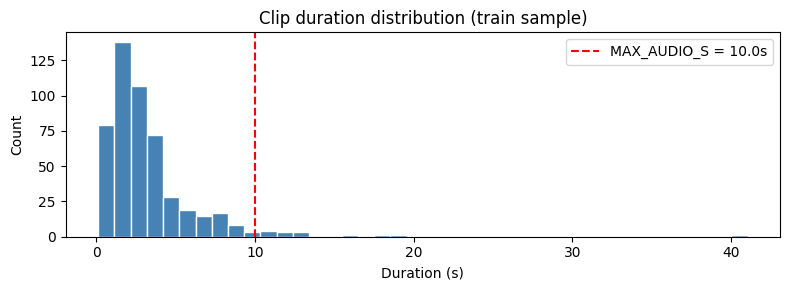

In [5]:
def get_duration_s(audio_dir, filename):
    path = os.path.join(audio_dir, filename)
    info = torchaudio.info(path)
    return info.num_frames / info.sample_rate

sample_files = train_df_audio['filename'].sample(min(500, len(train_df_audio)), random_state=42)
durations = [get_duration_s(AUDIO_TRAIN_DIR, f) for f in sample_files]

print(f'Duration stats (sampled {len(durations)} files):')
print(f'  mean  : {np.mean(durations):.2f} s')
print(f'  median: {np.median(durations):.2f} s')
print(f'  max   : {np.max(durations):.2f} s')
print(f'  >MAX_AUDIO_S ({MAX_AUDIO_S}s): {sum(d > MAX_AUDIO_S for d in durations)} clips')

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(durations, bins=40, color='steelblue', edgecolor='white')
ax.axvline(MAX_AUDIO_S, color='red', linestyle='--', label=f'MAX_AUDIO_S = {MAX_AUDIO_S}s')
ax.set_xlabel('Duration (s)')
ax.set_ylabel('Count')
ax.set_title('Clip duration distribution (train sample)')
ax.legend()
plt.tight_layout()
plt.show()

## Step 4 — Visualise trim effect on a sample clip

Shows a waveform before and after applying `TRIM_START_S` / `TRIM_END_S`.
Useful for tuning the trim parameters in `src/config.py`.

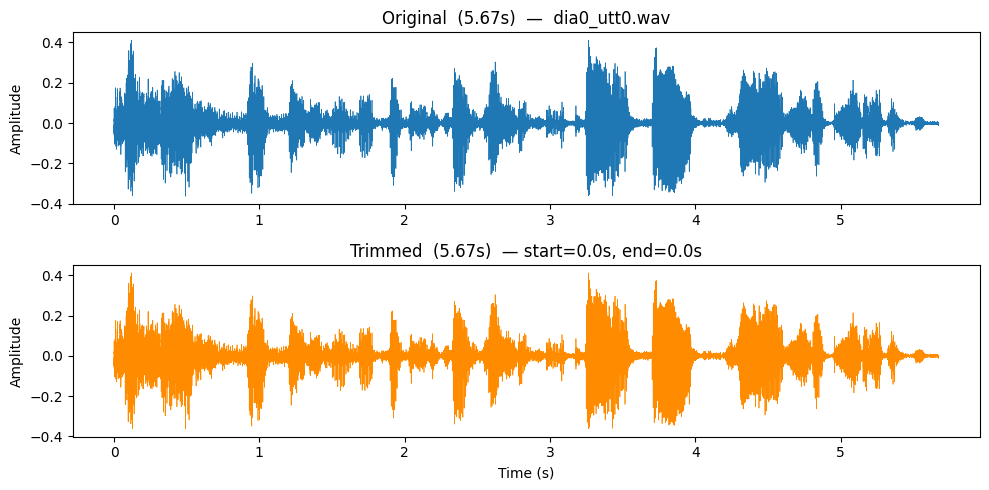

In [6]:
sample_filename = train_df_audio['filename'].iloc[0]
sample_path     = os.path.join(AUDIO_TRAIN_DIR, sample_filename)

waveform, sr = torchaudio.load(sample_path)
if sr != SAMPLE_RATE:
    waveform = torchaudio.functional.resample(waveform, sr, SAMPLE_RATE)
if waveform.shape[0] > 1:
    waveform = waveform.mean(dim=0, keepdim=True)
waveform = waveform.squeeze(0).numpy()

trim_start_samples = int(TRIM_START_S * SAMPLE_RATE)
trim_end_samples   = int(TRIM_END_S   * SAMPLE_RATE)
end_idx = len(waveform) - trim_end_samples if trim_end_samples > 0 else len(waveform)
trimmed = waveform[trim_start_samples:end_idx]

t_orig    = np.linspace(0, len(waveform) / SAMPLE_RATE, len(waveform))
t_trimmed = np.linspace(0, len(trimmed)  / SAMPLE_RATE, len(trimmed))

fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=False)
axes[0].plot(t_orig,    waveform, linewidth=0.5)
axes[0].set_title(f'Original  ({len(waveform)/SAMPLE_RATE:.2f}s)  —  {sample_filename}')
axes[0].set_ylabel('Amplitude')
axes[1].plot(t_trimmed, trimmed,  linewidth=0.5, color='darkorange')
axes[1].set_title(f'Trimmed  ({len(trimmed)/SAMPLE_RATE:.2f}s)  — start={TRIM_START_S}s, end={TRIM_END_S}s')
axes[1].set_ylabel('Amplitude')
axes[1].set_xlabel('Time (s)')
plt.tight_layout()
plt.show()

## Step 5 — Sanity checks

In [7]:
for name, df in [('train', train_df_audio), ('dev', dev_df_audio), ('test', test_df_audio)]:
    assert df['label'].dtype == int, f'{name}: label dtype is {df["label"].dtype}'
    assert df.isna().sum().sum() == 0, f'{name}: contains NaN values'
    print(f'[{name}] OK — {len(df):,} rows')

train_df_audio.head()

[train] OK — 9,988 rows
[dev] OK — 1,108 rows
[test] OK — 2,610 rows


,filename,emotion,label
0,dia0_utt0.wav,neutral,4
1,dia0_utt1.wav,neutral,4
2,dia0_utt2.wav,neutral,4
3,dia0_utt3.wav,neutral,4
4,dia0_utt4.wav,surprise,6
